<a href="https://colab.research.google.com/github/rjay45w/ITEM_MANAGER/blob/main/FootballPredictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import os

db_path = "/content/drive/MyDrive/ml/database.sqlite"

print("File exists:", os.path.isfile(db_path))

if os.path.isfile(db_path):
    print("File size (MB):", round(os.path.getsize(db_path) / (1024**2), 2))

File exists: True
File size (MB): 298.59


In [12]:
import sqlite3

DB_PATH = "/content/drive/MyDrive/ml/database.sqlite"

con = sqlite3.connect(DB_PATH)

print("Database connected successfully!")

Database connected successfully!


In [13]:
import pandas as pd

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    con
)

display(tables)

,name
0,Country
1,League
2,Match
3,Player
4,Player_Attributes
5,Team
6,Team_Attributes
7,sqlite_sequence


In [14]:
match_columns = pd.read_sql_query(
    "PRAGMA table_info('Match');",
    con
)

display(match_columns[['name', 'type']])

,name,type
0,id,INTEGER
1,country_id,INTEGER
2,league_id,INTEGER
3,season,TEXT
4,stage,INTEGER
...,...,...
110,GBD,NUMERIC
111,GBA,NUMERIC
112,BSH,NUMERIC
113,BSD,NUMERIC


In [15]:
matches_sample = pd.read_sql_query(
    "SELECT * FROM Match LIMIT 5;",
    con
)

display(matches_sample)

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


In [16]:
leagues = pd.read_sql_query(
    "SELECT * FROM League;",
    con
)

display(leagues)

,id,country_id,name
0,1,1,Belgium Jupiler League
1,1729,1729,England Premier League
2,4769,4769,France Ligue 1
3,7809,7809,Germany 1. Bundesliga
4,10257,10257,Italy Serie A
5,13274,13274,Netherlands Eredivisie
6,15722,15722,Poland Ekstraklasa
7,17642,17642,Portugal Liga ZON Sagres
8,19694,19694,Scotland Premier League
9,21518,21518,Spain LIGA BBVA


In [17]:
epl_matches = pd.read_sql_query(
    """
    SELECT *
    FROM Match
    WHERE league_id = 1729
    ORDER BY date;
    """,
    con
)

print("EPL matches:", len(epl_matches))
display(epl_matches.head())

EPL matches: 3040


,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1730,1729,1729,2008/2009,1,2008-08-16 00:00:00,489043,9825,8659,1,...,12.00,1.25,6.0,13.00,1.22,5.50,13.00,1.22,5.00,13.00
1,1731,1729,1729,2008/2009,1,2008-08-16 00:00:00,489044,8472,8650,0,...,1.73,5.50,3.8,1.65,5.00,3.40,1.70,4.50,3.40,1.73
2,1732,1729,1729,2008/2009,1,2008-08-16 00:00:00,489045,8654,8528,2,...,3.75,1.90,3.5,4.35,1.91,3.25,4.00,1.91,3.25,3.80
3,1734,1729,1729,2008/2009,1,2008-08-16 00:00:00,489047,8668,8655,2,...,3.40,2.05,3.3,4.00,2.00,3.25,3.75,2.00,3.25,3.50
4,1735,1729,1729,2008/2009,1,2008-08-16 00:00:00,489048,8549,8586,2,...,2.20,3.20,3.4,2.30,3.00,3.25,2.30,2.80,3.25,2.30


In [19]:
epl_matches['result'] = epl_matches.apply(
    lambda row: 'H' if row['home_team_goal'] > row['away_team_goal']
    else 'D' if row['home_team_goal'] == row['away_team_goal']
    else 'A',
    axis=1
)

display(
    epl_matches[
        ['date', 'home_team_api_id', 'away_team_api_id',
         'home_team_goal', 'away_team_goal', 'result']
    ].head(10)
)

,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,result
0,2008-08-16 00:00:00,9825,8659,1,0,H
1,2008-08-16 00:00:00,8472,8650,0,1,A
2,2008-08-16 00:00:00,8654,8528,2,1,H
3,2008-08-16 00:00:00,8668,8655,2,3,A
4,2008-08-16 00:00:00,8549,8586,2,1,H
5,2008-08-16 00:00:00,8559,10194,3,1,H
6,2008-08-16 00:00:00,8667,9879,2,1,H
7,2008-08-17 00:00:00,10260,10261,1,1,D
8,2008-08-17 00:00:00,10252,8456,4,2,H
9,2008-08-17 00:00:00,8455,8462,4,0,H


In [20]:
print(epl_matches['result'].value_counts())

print("\nPercentages:")
print((epl_matches['result'].value_counts(normalize=True) * 100).round(2))

result
H    1390
A     867
D     783
Name: count, dtype: int64

Percentages:
result
H    45.72
A    28.52
D    25.76
Name: proportion, dtype: float64


In [21]:
teams = pd.read_sql_query(
    """
    SELECT team_api_id, team_long_name, team_short_name
    FROM Team;
    """,
    con
)

display(teams.head(10))

,team_api_id,team_long_name,team_short_name
0,9987,KRC Genk,GEN
1,9993,Beerschot AC,BAC
2,10000,SV Zulte-Waregem,ZUL
3,9994,Sporting Lokeren,LOK
4,9984,KSV Cercle Brugge,CEB
5,8635,RSC Anderlecht,AND
6,9991,KAA Gent,GEN
7,9998,RAEC Mons,MON
8,7947,FCV Dender EH,DEN
9,9985,Standard de Liège,STL


In [22]:
epl_team_ids = pd.concat([
    epl_matches['home_team_api_id'],
    epl_matches['away_team_api_id']
]).unique()

epl_teams = teams[teams['team_api_id'].isin(epl_team_ids)]

print("Number of EPL teams:", len(epl_teams))
display(epl_teams.sort_values('team_long_name'))

Number of EPL teams: 34


,team_api_id,team_long_name,team_short_name
27,9825,Arsenal,ARS
33,10252,Aston Villa,AVL
45,8658,Birmingham City,BIR
36,8655,Blackburn Rovers,BLB
48,8483,Blackpool,BLA
39,8559,Bolton Wanderers,BOL
57,8678,Bournemouth,BOU
47,8191,Burnley,BUR
55,8344,Cardiff City,CAR
43,8455,Chelsea,CHE


In [23]:
display(epl_teams[['team_api_id', 'team_long_name']].sort_values('team_long_name'))

,team_api_id,team_long_name
27,9825,Arsenal
33,10252,Aston Villa
45,8658,Birmingham City
36,8655,Blackburn Rovers
48,8483,Blackpool
39,8559,Bolton Wanderers
57,8678,Bournemouth
47,8191,Burnley
55,8344,Cardiff City
43,8455,Chelsea


In [24]:
# Add home team name
epl_matches = epl_matches.merge(
    teams[['team_api_id', 'team_long_name']],
    left_on='home_team_api_id',
    right_on='team_api_id',
    how='left'
)

epl_matches = epl_matches.rename(columns={
    'team_long_name': 'home_team'
})

epl_matches = epl_matches.drop(columns=['team_api_id'])


# Add away team name
epl_matches = epl_matches.merge(
    teams[['team_api_id', 'team_long_name']],
    left_on='away_team_api_id',
    right_on='team_api_id',
    how='left'
)

epl_matches = epl_matches.rename(columns={
    'team_long_name': 'away_team'
})

epl_matches = epl_matches.drop(columns=['team_api_id'])


display(
    epl_matches[
        ['date', 'home_team', 'away_team',
         'home_team_goal', 'away_team_goal', 'result']
    ].head(10)
)

,date,home_team,away_team,home_team_goal,away_team_goal,result
0,2008-08-16 00:00:00,Arsenal,West Bromwich Albion,1,0,H
1,2008-08-16 00:00:00,Sunderland,Liverpool,0,1,A
2,2008-08-16 00:00:00,West Ham United,Wigan Athletic,2,1,H
3,2008-08-16 00:00:00,Everton,Blackburn Rovers,2,3,A
4,2008-08-16 00:00:00,Middlesbrough,Tottenham Hotspur,2,1,H
5,2008-08-16 00:00:00,Bolton Wanderers,Stoke City,3,1,H
6,2008-08-16 00:00:00,Hull City,Fulham,2,1,H
7,2008-08-17 00:00:00,Manchester United,Newcastle United,1,1,D
8,2008-08-17 00:00:00,Aston Villa,Manchester City,4,2,H
9,2008-08-17 00:00:00,Chelsea,Portsmouth,4,0,H


In [19]:
print("Missing home teams:", epl_matches['home_team'].isna().sum())
print("Missing away teams:", epl_matches['away_team'].isna().sum())

Missing home teams: 0
Missing away teams: 0


In [25]:
epl_matches['date'] = pd.to_datetime(epl_matches['date'])

epl_matches = epl_matches.sort_values('date').reset_index(drop=True)

display(
    epl_matches[['date', 'home_team', 'away_team', 'result']].head(10)
)

,date,home_team,away_team,result
0,2008-08-16,Arsenal,West Bromwich Albion,H
1,2008-08-16,Sunderland,Liverpool,A
2,2008-08-16,West Ham United,Wigan Athletic,H
3,2008-08-16,Everton,Blackburn Rovers,A
4,2008-08-16,Middlesbrough,Tottenham Hotspur,H
5,2008-08-16,Bolton Wanderers,Stoke City,H
6,2008-08-16,Hull City,Fulham,H
7,2008-08-17,Manchester United,Newcastle United,D
8,2008-08-17,Aston Villa,Manchester City,H
9,2008-08-17,Chelsea,Portsmouth,H


In [26]:
# Store each team's previous results
team_history = {}

home_form = []
away_form = []

for _, match in epl_matches.iterrows():

    home = match['home_team']
    away = match['away_team']

    # Only use matches BEFORE the current match
    home_previous = team_history.get(home, [])[-5:]
    away_previous = team_history.get(away, [])[-5:]

    # Average points from previous 5 matches
    home_form.append(
        sum(home_previous) / len(home_previous)
        if home_previous else 0
    )

    away_form.append(
        sum(away_previous) / len(away_previous)
        if away_previous else 0
    )

    # Update history AFTER creating the features
    if match['result'] == 'H':
        home_points, away_points = 3, 0
    elif match['result'] == 'D':
        home_points, away_points = 1, 1
    else:
        home_points, away_points = 0, 3

    team_history.setdefault(home, []).append(home_points)
    team_history.setdefault(away, []).append(away_points)

epl_matches['home_form'] = home_form
epl_matches['away_form'] = away_form

display(
    epl_matches[
        ['date', 'home_team', 'away_team',
         'home_form', 'away_form', 'result']
    ].head(15)
)

,date,home_team,away_team,home_form,away_form,result
0,2008-08-16,Arsenal,West Bromwich Albion,0.0,0.0,H
1,2008-08-16,Sunderland,Liverpool,0.0,0.0,A
2,2008-08-16,West Ham United,Wigan Athletic,0.0,0.0,H
3,2008-08-16,Everton,Blackburn Rovers,0.0,0.0,A
4,2008-08-16,Middlesbrough,Tottenham Hotspur,0.0,0.0,H
5,2008-08-16,Bolton Wanderers,Stoke City,0.0,0.0,H
6,2008-08-16,Hull City,Fulham,0.0,0.0,H
7,2008-08-17,Manchester United,Newcastle United,0.0,0.0,D
8,2008-08-17,Aston Villa,Manchester City,0.0,0.0,H
9,2008-08-17,Chelsea,Portsmouth,0.0,0.0,H


In [27]:
display(
    epl_matches[
        ['date', 'home_team', 'away_team', 'home_form', 'away_form', 'result']
    ].iloc[20:30]
)

,date,home_team,away_team,home_form,away_form,result
20,2008-08-30,Bolton Wanderers,West Bromwich Albion,1.5,0.0,D
21,2008-08-30,Hull City,Wigan Athletic,2.0,0.0,A
22,2008-08-30,Middlesbrough,Stoke City,1.5,1.5,H
23,2008-08-30,Everton,Portsmouth,1.5,0.0,A
24,2008-08-30,West Ham United,Blackburn Rovers,1.5,2.0,H
25,2008-08-30,Arsenal,Newcastle United,1.5,2.0,H
26,2008-08-31,Sunderland,Manchester City,1.5,1.5,A
27,2008-08-31,Aston Villa,Liverpool,1.5,3.0,D
28,2008-08-31,Chelsea,Tottenham Hotspur,3.0,0.0,D
29,2008-09-13,Wigan Athletic,Sunderland,1.0,1.0,D


In [28]:
team_goals_history = {}

home_goals_form = []
away_goals_form = []

for _, match in epl_matches.iterrows():

    home = match['home_team']
    away = match['away_team']

    home_previous_goals = team_goals_history.get(home, [])[-5:]
    away_previous_goals = team_goals_history.get(away, [])[-5:]

    home_goals_form.append(
        sum(home_previous_goals) / len(home_previous_goals)
        if home_previous_goals else 0
    )

    away_goals_form.append(
        sum(away_previous_goals) / len(away_previous_goals)
        if away_previous_goals else 0
    )

    # Update history AFTER creating the current-match features
    team_goals_history.setdefault(home, []).append(
        match['home_team_goal']
    )

    team_goals_history.setdefault(away, []).append(
        match['away_team_goal']
    )

epl_matches['home_goals_form'] = home_goals_form
epl_matches['away_goals_form'] = away_goals_form

display(
    epl_matches[
        ['date', 'home_team', 'away_team',
         'home_goals_form', 'away_goals_form', 'result']
    ].iloc[20:30]
)

,date,home_team,away_team,home_goals_form,away_goals_form,result
20,2008-08-30,Bolton Wanderers,West Bromwich Albion,1.5,0.500000,D
21,2008-08-30,Hull City,Wigan Athletic,1.5,0.500000,A
22,2008-08-30,Middlesbrough,Stoke City,1.5,2.000000,H
23,2008-08-30,Everton,Portsmouth,2.0,0.000000,A
24,2008-08-30,West Ham United,Blackburn Rovers,1.0,2.000000,H
25,2008-08-30,Arsenal,Newcastle United,0.5,1.000000,H
26,2008-08-31,Sunderland,Manchester City,1.0,2.500000,A
27,2008-08-31,Aston Villa,Liverpool,3.0,1.500000,D
28,2008-08-31,Chelsea,Tottenham Hotspur,2.5,1.000000,D
29,2008-09-13,Wigan Athletic,Sunderland,2.0,0.666667,D


In [29]:
team_conceded_history = {}

home_conceded_form = []
away_conceded_form = []

for _, match in epl_matches.iterrows():

    home = match['home_team']
    away = match['away_team']

    home_previous = team_conceded_history.get(home, [])[-5:]
    away_previous = team_conceded_history.get(away, [])[-5:]

    home_conceded_form.append(
        sum(home_previous) / len(home_previous)
        if home_previous else 0
    )

    away_conceded_form.append(
        sum(away_previous) / len(away_previous)
        if away_previous else 0
    )

    # Update AFTER creating the current-match features
    team_conceded_history.setdefault(home, []).append(
        match['away_team_goal']
    )

    team_conceded_history.setdefault(away, []).append(
        match['home_team_goal']
    )

epl_matches['home_conceded_form'] = home_conceded_form
epl_matches['away_conceded_form'] = away_conceded_form

display(
    epl_matches[
        ['date', 'home_team', 'away_team',
         'home_conceded_form', 'away_conceded_form', 'result']
    ].iloc[20:30]
)

,date,home_team,away_team,home_conceded_form,away_conceded_form,result
20,2008-08-30,Bolton Wanderers,West Bromwich Albion,1.0,1.500000,D
21,2008-08-30,Hull City,Wigan Athletic,1.0,1.500000,A
22,2008-08-30,Middlesbrough,Stoke City,1.5,2.500000,H
23,2008-08-30,Everton,Portsmouth,2.0,2.500000,A
24,2008-08-30,West Ham United,Blackburn Rovers,2.0,1.500000,H
25,2008-08-30,Arsenal,Newcastle United,0.5,0.500000,H
26,2008-08-31,Sunderland,Manchester City,1.0,2.000000,A
27,2008-08-31,Aston Villa,Liverpool,2.5,0.500000,D
28,2008-08-31,Chelsea,Tottenham Hotspur,0.0,2.000000,D
29,2008-09-13,Wigan Athletic,Sunderland,1.0,1.666667,D


In [30]:
display(
    epl_matches[
        [
            'date',
            'home_team',
            'away_team',
            'home_form',
            'away_form',
            'home_goals_form',
            'away_goals_form',
            'home_conceded_form',
            'away_conceded_form',
            'result'
        ]
    ].iloc[20:30]
)

,date,home_team,away_team,home_form,away_form,home_goals_form,away_goals_form,home_conceded_form,away_conceded_form,result
20,2008-08-30,Bolton Wanderers,West Bromwich Albion,1.5,0.0,1.5,0.500000,1.0,1.500000,D
21,2008-08-30,Hull City,Wigan Athletic,2.0,0.0,1.5,0.500000,1.0,1.500000,A
22,2008-08-30,Middlesbrough,Stoke City,1.5,1.5,1.5,2.000000,1.5,2.500000,H
23,2008-08-30,Everton,Portsmouth,1.5,0.0,2.0,0.000000,2.0,2.500000,A
24,2008-08-30,West Ham United,Blackburn Rovers,1.5,2.0,1.0,2.000000,2.0,1.500000,H
25,2008-08-30,Arsenal,Newcastle United,1.5,2.0,0.5,1.000000,0.5,0.500000,H
26,2008-08-31,Sunderland,Manchester City,1.5,1.5,1.0,2.500000,1.0,2.000000,A
27,2008-08-31,Aston Villa,Liverpool,1.5,3.0,3.0,1.500000,2.5,0.500000,D
28,2008-08-31,Chelsea,Tottenham Hotspur,3.0,0.0,2.5,1.000000,0.0,2.000000,D
29,2008-09-13,Wigan Athletic,Sunderland,1.0,1.0,2.0,0.666667,1.0,1.666667,D


In [31]:
ml_data = epl_matches[
    (epl_matches['home_form'] > 0) &
    (epl_matches['away_form'] > 0)
].copy()

print("Original matches:", len(epl_matches))
print("Matches for ML:", len(ml_data))

display(
    ml_data[
        [
            'date',
            'home_team',
            'away_team',
            'home_form',
            'away_form',
            'home_goals_form',
            'away_goals_form',
            'home_conceded_form',
            'away_conceded_form',
            'result'
        ]
    ].head()
)

Original matches: 3040
Matches for ML: 2919


,date,home_team,away_team,home_form,away_form,home_goals_form,away_goals_form,home_conceded_form,away_conceded_form,result
14,2008-08-23,Newcastle United,Bolton Wanderers,1.0,3.0,1.0,3.0,1.0,1.0,H
15,2008-08-23,Liverpool,Middlesbrough,3.0,3.0,1.0,2.0,0.0,1.0,H
16,2008-08-23,Blackburn Rovers,Hull City,3.0,3.0,3.0,2.0,2.0,1.0,D
22,2008-08-30,Middlesbrough,Stoke City,1.5,1.5,1.5,2.0,1.5,2.5,H
24,2008-08-30,West Ham United,Blackburn Rovers,1.5,2.0,1.0,2.0,2.0,1.5,H


In [32]:
feature_columns = [
    'home_form',
    'away_form',
    'home_goals_form',
    'away_goals_form',
    'home_conceded_form',
    'away_conceded_form'
]

X = ml_data[feature_columns]
y = ml_data['result']

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (2919, 6)
y shape: (2919,)


,home_form,away_form,home_goals_form,away_goals_form,home_conceded_form,away_conceded_form
14,1.0,3.0,1.0,3.0,1.0,1.0
15,3.0,3.0,1.0,2.0,0.0,1.0
16,3.0,3.0,3.0,2.0,2.0,1.0
22,1.5,1.5,1.5,2.0,1.5,2.5
24,1.5,2.0,1.0,2.0,2.0,1.5


,result
14,H
15,H
16,D
22,H
24,H


In [33]:
split_index = int(len(ml_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training matches:", len(X_train))
print("Testing matches:", len(X_test))

print("\nTraining period:")
print(ml_data['date'].iloc[0], "to", ml_data['date'].iloc[split_index - 1])

print("\nTesting period:")
print(ml_data['date'].iloc[split_index], "to", ml_data['date'].iloc[-1])

Training matches: 2335
Testing matches: 584

Training period:
2008-08-23 00:00:00 to 2014-12-07 00:00:00

Testing period:
2014-12-08 00:00:00 to 2016-05-17 00:00:00


In [34]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

baseline = DummyClassifier(strategy='most_frequent')

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("Baseline Accuracy:", round(accuracy_score(y_test, baseline_pred), 4))
print("Baseline Macro F1:", round(f1_score(y_test, baseline_pred, average='macro'), 4))

Baseline Accuracy: 0.4384
Baseline Macro F1: 0.2032


In [35]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

print("Logistic Regression Accuracy:",
      round(accuracy_score(y_test, logistic_pred), 4))

print("Logistic Regression Macro F1:",
      round(f1_score(y_test, logistic_pred, average='macro'), 4))

Logistic Regression Accuracy: 0.4863
Logistic Regression Macro F1: 0.3347


In [36]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Accuracy:",
      round(accuracy_score(y_test, tree_pred), 4))

print("Decision Tree Macro F1:",
      round(f1_score(y_test, tree_pred, average='macro'), 4))

Decision Tree Accuracy: 0.4658
Decision Tree Macro F1: 0.3249


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      round(accuracy_score(y_test, rf_pred), 4))

print("Random Forest Macro F1:",
      round(f1_score(y_test, rf_pred, average='macro'), 4))

Random Forest Accuracy: 0.4846
Random Forest Macro F1: 0.3358


In [38]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    y_test,
    rf_pred,
    labels=['H', 'D', 'A']
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_test,
    rf_pred,
    labels=['H', 'D', 'A']
))


              precision    recall  f1-score   support

           H       0.49      0.90      0.63       256
           D       0.20      0.01      0.01       151
           A       0.49      0.29      0.36       177

    accuracy                           0.48       584
   macro avg       0.39      0.40      0.34       584
weighted avg       0.41      0.48      0.39       584

Confusion Matrix:
[[231   2  23]
 [119   1  31]
 [124   2  51]]


In [39]:
print(classification_report(
    y_test,
    logistic_pred,
    labels=['H', 'D', 'A']
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_test,
    logistic_pred,
    labels=['H', 'D', 'A']
))

              precision    recall  f1-score   support

           H       0.49      0.91      0.64       256
           D       0.33      0.01      0.01       151
           A       0.48      0.28      0.35       177

    accuracy                           0.49       584
   macro avg       0.43      0.40      0.33       584
weighted avg       0.45      0.49      0.39       584

Confusion Matrix:
[[233   1  22]
 [117   1  33]
 [126   1  50]]


In [40]:
print(classification_report(
    y_test,
    tree_pred,
    labels=['H', 'D', 'A']
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_test,
    tree_pred,
    labels=['H', 'D', 'A']
))

              precision    recall  f1-score   support

           H       0.48      0.87      0.62       256
           D       0.15      0.01      0.02       151
           A       0.44      0.27      0.33       177

    accuracy                           0.47       584
   macro avg       0.36      0.38      0.32       584
weighted avg       0.38      0.47      0.38       584

Confusion Matrix:
[[223   4  29]
 [118   2  31]
 [123   7  47]]


In [41]:
results = pd.DataFrame({
    'Model': [
        'Baseline',
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Macro F1': [
        f1_score(y_test, baseline_pred, average='macro'),
        f1_score(y_test, logistic_pred, average='macro'),
        f1_score(y_test, tree_pred, average='macro'),
        f1_score(y_test, rf_pred, average='macro')
    ]
})

results['Accuracy'] = results['Accuracy'].round(4)
results['Macro F1'] = results['Macro F1'].round(4)

display(results)

,Model,Accuracy,Macro F1
0,Baseline,0.4384,0.2032
1,Logistic Regression,0.4863,0.3347
2,Decision Tree,0.4658,0.3249
3,Random Forest,0.4846,0.3358


In [42]:
home_history = {}
away_history = {}

home_specific_form = []
away_specific_form = []

for _, match in epl_matches.iterrows():

    home = match['home_team']
    away = match['away_team']

    # Previous home-match points for the home team
    previous_home = home_history.get(home, [])[-5:]

    # Previous away-match points for the away team
    previous_away = away_history.get(away, [])[-5:]

    home_specific_form.append(
        sum(previous_home) / len(previous_home)
        if previous_home else 0
    )

    away_specific_form.append(
        sum(previous_away) / len(previous_away)
        if previous_away else 0
    )

    # Calculate points from CURRENT match
    if match['result'] == 'H':
        home_points, away_points = 3, 0
    elif match['result'] == 'D':
        home_points, away_points = 1, 1
    else:
        home_points, away_points = 0, 3

    # Update histories AFTER creating features
    home_history.setdefault(home, []).append(home_points)
    away_history.setdefault(away, []).append(away_points)

epl_matches['home_team_home_form'] = home_specific_form
epl_matches['away_team_away_form'] = away_specific_form

display(
    epl_matches[
        [
            'date',
            'home_team',
            'away_team',
            'home_team_home_form',
            'away_team_away_form',
            'result'
        ]
    ].iloc[20:30]
)

,date,home_team,away_team,home_team_home_form,away_team_away_form,result
20,2008-08-30,Bolton Wanderers,West Bromwich Albion,3.0,0.0,D
21,2008-08-30,Hull City,Wigan Athletic,3.0,0.0,A
22,2008-08-30,Middlesbrough,Stoke City,3.0,0.0,H
23,2008-08-30,Everton,Portsmouth,0.0,0.0,A
24,2008-08-30,West Ham United,Blackburn Rovers,3.0,3.0,H
25,2008-08-30,Arsenal,Newcastle United,3.0,1.0,H
26,2008-08-31,Sunderland,Manchester City,0.0,0.0,A
27,2008-08-31,Aston Villa,Liverpool,3.0,3.0,D
28,2008-08-31,Chelsea,Tottenham Hotspur,3.0,0.0,D
29,2008-09-13,Wigan Athletic,Sunderland,0.0,3.0,D


In [43]:

epl_matches = pd.read_sql_query(
    """
    SELECT *
    FROM Match
    WHERE league_id = 1729
    ORDER BY date;
    """,
    con
)

epl_matches['result'] = epl_matches.apply(
    lambda row: 'H' if row['home_team_goal'] > row['away_team_goal']
    else 'D' if row['home_team_goal'] == row['away_team_goal']
    else 'A',
    axis=1
)

epl_matches['date'] = pd.to_datetime(epl_matches['date'])

# Add home team names
epl_matches = epl_matches.merge(
    teams[['team_api_id', 'team_long_name']],
    left_on='home_team_api_id',
    right_on='team_api_id',
    how='left'
).rename(columns={'team_long_name': 'home_team'})

epl_matches = epl_matches.drop(columns=['team_api_id'])

# Add away team names
epl_matches = epl_matches.merge(
    teams[['team_api_id', 'team_long_name']],
    left_on='away_team_api_id',
    right_on='team_api_id',
    how='left'
).rename(columns={'team_long_name': 'away_team'})

epl_matches = epl_matches.drop(columns=['team_api_id'])

epl_matches = epl_matches.sort_values('date').reset_index(drop=True)

print("EPL matches rebuilt:", len(epl_matches))


EPL matches rebuilt: 3040


In [44]:
# Store each team's previous match points and goals
team_history = {}
team_goals_history = {}
team_conceded_history = {}

home_form = []
away_form = []
home_goals_form = []
away_goals_form = []
home_conceded_form = []
away_conceded_form = []

for _, match in epl_matches.iterrows():

    home = match['home_team']
    away = match['away_team']

    # ----- BEFORE the current match -----
    home_previous = team_history.get(home, [])[-5:]
    away_previous = team_history.get(away, [])[-5:]

    home_goals_previous = team_goals_history.get(home, [])[-5:]
    away_goals_previous = team_goals_history.get(away, [])[-5:]

    home_conceded_previous = team_conceded_history.get(home, [])[-5:]
    away_conceded_previous = team_conceded_history.get(away, [])[-5:]

    # Recent points per match
    home_form.append(
        sum(home_previous) / len(home_previous)
        if home_previous else 0
    )

    away_form.append(
        sum(away_previous) / len(away_previous)
        if away_previous else 0
    )

    # Recent goals scored
    home_goals_form.append(
        sum(home_goals_previous) / len(home_goals_previous)
        if home_goals_previous else 0
    )

    away_goals_form.append(
        sum(away_goals_previous) / len(away_goals_previous)
        if away_goals_previous else 0
    )

    # Recent goals conceded
    home_conceded_form.append(
        sum(home_conceded_previous) / len(home_conceded_previous)
        if home_conceded_previous else 0
    )

    away_conceded_form.append(
        sum(away_conceded_previous) / len(away_conceded_previous)
        if away_conceded_previous else 0
    )

    # ----- AFTER creating features, update history -----
    if match['result'] == 'H':
        home_points, away_points = 3, 0
    elif match['result'] == 'D':
        home_points, away_points = 1, 1
    else:
        home_points, away_points = 0, 3

    team_history.setdefault(home, []).append(home_points)
    team_history.setdefault(away, []).append(away_points)

    team_goals_history.setdefault(home, []).append(match['home_team_goal'])
    team_goals_history.setdefault(away, []).append(match['away_team_goal'])

    team_conceded_history.setdefault(home, []).append(match['away_team_goal'])
    team_conceded_history.setdefault(away, []).append(match['home_team_goal'])

# Add features to dataframe
epl_matches['home_form'] = home_form
epl_matches['away_form'] = away_form
epl_matches['home_goals_form'] = home_goals_form
epl_matches['away_goals_form'] = away_goals_form
epl_matches['home_conceded_form'] = home_conceded_form
epl_matches['away_conceded_form'] = away_conceded_form

print("Features created successfully!")

display(
    epl_matches[
        [
            'date',
            'home_team',
            'away_team',
            'home_form',
            'away_form',
            'home_goals_form',
            'away_goals_form',
            'home_conceded_form',
            'away_conceded_form',
            'result'
        ]
    ].iloc[20:30]
)

Features created successfully!


,date,home_team,away_team,home_form,away_form,home_goals_form,away_goals_form,home_conceded_form,away_conceded_form,result
20,2008-08-30,Bolton Wanderers,West Bromwich Albion,1.5,0.0,1.5,0.500000,1.0,1.500000,D
21,2008-08-30,Hull City,Wigan Athletic,2.0,0.0,1.5,0.500000,1.0,1.500000,A
22,2008-08-30,Middlesbrough,Stoke City,1.5,1.5,1.5,2.000000,1.5,2.500000,H
23,2008-08-30,Everton,Portsmouth,1.5,0.0,2.0,0.000000,2.0,2.500000,A
24,2008-08-30,West Ham United,Blackburn Rovers,1.5,2.0,1.0,2.000000,2.0,1.500000,H
25,2008-08-30,Arsenal,Newcastle United,1.5,2.0,0.5,1.000000,0.5,0.500000,H
26,2008-08-31,Sunderland,Manchester City,1.5,1.5,1.0,2.500000,1.0,2.000000,A
27,2008-08-31,Aston Villa,Liverpool,1.5,3.0,3.0,1.500000,2.5,0.500000,D
28,2008-08-31,Chelsea,Tottenham Hotspur,3.0,0.0,2.5,1.000000,0.0,2.000000,D
29,2008-09-13,Wigan Athletic,Sunderland,1.0,1.0,2.0,0.666667,1.0,1.666667,D


In [45]:
feature_columns = [
    'home_form',
    'away_form',
    'home_goals_form',
    'away_goals_form',
    'home_conceded_form',
    'away_conceded_form'
]

# Remove matches where we don't have previous history
ml_data = epl_matches[
    (epl_matches['home_form'] > 0) &
    (epl_matches['away_form'] > 0)
].copy()

# X = features, y = target
X = ml_data[feature_columns]
y = ml_data['result']

print("Original matches:", len(epl_matches))
print("Matches for ML:", len(ml_data))
print("Number of features:", len(feature_columns))

display(X.head())

Original matches: 3040
Matches for ML: 2919
Number of features: 6


,home_form,away_form,home_goals_form,away_goals_form,home_conceded_form,away_conceded_form
14,1.0,3.0,1.0,3.0,1.0,1.0
15,3.0,3.0,1.0,2.0,0.0,1.0
16,3.0,3.0,3.0,2.0,2.0,1.0
22,1.5,1.5,1.5,2.0,1.5,2.5
24,1.5,2.0,1.0,2.0,2.0,1.5


In [46]:
split_index = int(len(ml_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training matches:", len(X_train))
print("Testing matches:", len(X_test))

print("\nTraining period:")
print(ml_data['date'].iloc[0], "to", ml_data['date'].iloc[split_index - 1])

print("\nTesting period:")
print(ml_data['date'].iloc[split_index], "to", ml_data['date'].iloc[-1])

Training matches: 2335
Testing matches: 584

Training period:
2008-08-23 00:00:00 to 2014-12-07 00:00:00

Testing period:
2014-12-08 00:00:00 to 2016-05-17 00:00:00


In [47]:
home_history = {}
away_history = {}

home_team_home_form = []
away_team_away_form = []

for _, match in epl_matches.iterrows():

    home = match['home_team']
    away = match['away_team']

    # Previous home matches of the home team
    previous_home = home_history.get(home, [])[-5:]

    # Previous away matches of the away team
    previous_away = away_history.get(away, [])[-5:]

    home_team_home_form.append(
        sum(previous_home) / len(previous_home)
        if previous_home else 0
    )

    away_team_away_form.append(
        sum(previous_away) / len(previous_away)
        if previous_away else 0
    )

    # Current match points
    if match['result'] == 'H':
        home_points, away_points = 3, 0
    elif match['result'] == 'D':
        home_points, away_points = 1, 1
    else:
        home_points, away_points = 0, 3

    # Update AFTER creating the current-match features
    home_history.setdefault(home, []).append(home_points)
    away_history.setdefault(away, []).append(away_points)

epl_matches['home_team_home_form'] = home_team_home_form
epl_matches['away_team_away_form'] = away_team_away_form

display(
    epl_matches[
        [
            'date',
            'home_team',
            'away_team',
            'home_team_home_form',
            'away_team_away_form',
            'result'
        ]
    ].iloc[20:30]
)

,date,home_team,away_team,home_team_home_form,away_team_away_form,result
20,2008-08-30,Bolton Wanderers,West Bromwich Albion,3.0,0.0,D
21,2008-08-30,Hull City,Wigan Athletic,3.0,0.0,A
22,2008-08-30,Middlesbrough,Stoke City,3.0,0.0,H
23,2008-08-30,Everton,Portsmouth,0.0,0.0,A
24,2008-08-30,West Ham United,Blackburn Rovers,3.0,3.0,H
25,2008-08-30,Arsenal,Newcastle United,3.0,1.0,H
26,2008-08-31,Sunderland,Manchester City,0.0,0.0,A
27,2008-08-31,Aston Villa,Liverpool,3.0,3.0,D
28,2008-08-31,Chelsea,Tottenham Hotspur,3.0,0.0,D
29,2008-09-13,Wigan Athletic,Sunderland,0.0,3.0,D


In [48]:
feature_columns_v2 = [
    'home_form',
    'away_form',
    'home_goals_form',
    'away_goals_form',
    'home_conceded_form',
    'away_conceded_form',
    'home_team_home_form',
    'away_team_away_form'
]

ml_data_v2 = epl_matches[
    (epl_matches['home_form'] > 0) &
    (epl_matches['away_form'] > 0) &
    (epl_matches['home_team_home_form'] > 0) &
    (epl_matches['away_team_away_form'] > 0)
].copy()

X_v2 = ml_data_v2[feature_columns_v2]
y_v2 = ml_data_v2['result']

print("Matches:", len(ml_data_v2))
print("Features:", len(feature_columns_v2))

display(X_v2.head())

Matches: 2759
Features: 8


,home_form,away_form,home_goals_form,away_goals_form,home_conceded_form,away_conceded_form,home_team_home_form,away_team_away_form
24,1.500000,2.000000,1.000000,2.0,2.000000,1.500000,3.0,3.0
25,1.500000,2.000000,0.500000,1.0,0.500000,0.500000,3.0,1.0
27,1.500000,3.000000,3.000000,1.5,2.500000,0.500000,3.0,3.0
33,2.000000,2.333333,2.666667,2.0,1.333333,0.333333,3.0,3.0
34,1.333333,1.333333,0.666667,1.0,1.333333,2.333333,3.0,1.0


In [49]:
split_index_v2 = int(len(ml_data_v2) * 0.8)

X_train_v2 = X_v2.iloc[:split_index_v2]
X_test_v2 = X_v2.iloc[split_index_v2:]

y_train_v2 = y_v2.iloc[:split_index_v2]
y_test_v2 = y_v2.iloc[split_index_v2:]

print("Training matches:", len(X_train_v2))
print("Testing matches:", len(X_test_v2))

print("\nTraining period:")
print(
    ml_data_v2['date'].iloc[0],
    "to",
    ml_data_v2['date'].iloc[split_index_v2 - 1]
)

print("\nTesting period:")
print(
    ml_data_v2['date'].iloc[split_index_v2],
    "to",
    ml_data_v2['date'].iloc[-1]
)

Training matches: 2207
Testing matches: 552

Training period:
2008-08-30 00:00:00 to 2014-12-13 00:00:00

Testing period:
2014-12-13 00:00:00 to 2016-05-17 00:00:00


In [50]:
# Logistic Regression
logistic_v2 = LogisticRegression(max_iter=1000)
logistic_v2.fit(X_train_v2, y_train_v2)
logistic_pred_v2 = logistic_v2.predict(X_test_v2)

# Decision Tree
tree_v2 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
tree_v2.fit(X_train_v2, y_train_v2)
tree_pred_v2 = tree_v2.predict(X_test_v2)

# Random Forest
rf_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)
rf_v2.fit(X_train_v2, y_train_v2)
rf_pred_v2 = rf_v2.predict(X_test_v2)

print("Experiment 2 models trained successfully!")

Experiment 2 models trained successfully!


In [51]:
results_v2 = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test_v2, logistic_pred_v2),
        accuracy_score(y_test_v2, tree_pred_v2),
        accuracy_score(y_test_v2, rf_pred_v2)
    ],
    'Macro F1': [
        f1_score(y_test_v2, logistic_pred_v2, average='macro'),
        f1_score(y_test_v2, tree_pred_v2, average='macro'),
        f1_score(y_test_v2, rf_pred_v2, average='macro')
    ]
})

results_v2['Accuracy'] = results_v2['Accuracy'].round(4)
results_v2['Macro F1'] = results_v2['Macro F1'].round(4)

display(results_v2)

,Model,Accuracy,Macro F1
0,Logistic Regression,0.4728,0.3442
1,Decision Tree,0.4420,0.3142
2,Random Forest,0.4692,0.3261


In [52]:
results_v2 = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test_v2, logistic_pred_v2),
        accuracy_score(y_test_v2, tree_pred_v2),
        accuracy_score(y_test_v2, rf_pred_v2)
    ],
    'Macro F1': [
        f1_score(y_test_v2, logistic_pred_v2, average='macro'),
        f1_score(y_test_v2, tree_pred_v2, average='macro'),
        f1_score(y_test_v2, rf_pred_v2, average='macro')
    ]
})

results_v2['Accuracy'] = results_v2['Accuracy'].round(4)
results_v2['Macro F1'] = results_v2['Macro F1'].round(4)

display(results_v2)

,Model,Accuracy,Macro F1
0,Logistic Regression,0.4728,0.3442
1,Decision Tree,0.4420,0.3142
2,Random Forest,0.4692,0.3261


In [53]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Exp 1 Accuracy': [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Exp 2 Accuracy': [
        accuracy_score(y_test_v2, logistic_pred_v2),
        accuracy_score(y_test_v2, tree_pred_v2),
        accuracy_score(y_test_v2, rf_pred_v2)
    ],
    'Exp 1 Macro F1': [
        f1_score(y_test, logistic_pred, average='macro'),
        f1_score(y_test, tree_pred, average='macro'),
        f1_score(y_test, rf_pred, average='macro')
    ],
    'Exp 2 Macro F1': [
        f1_score(y_test_v2, logistic_pred_v2, average='macro'),
        f1_score(y_test_v2, tree_pred_v2, average='macro'),
        f1_score(y_test_v2, rf_pred_v2, average='macro')
    ]
})

comparison.iloc[:, 1:] = comparison.iloc[:, 1:].round(4)

display(comparison)

,Model,Exp 1 Accuracy,Exp 2 Accuracy,Exp 1 Macro F1,Exp 2 Macro F1
0,Logistic Regression,0.4863,0.4728,0.3347,0.3442
1,Decision Tree,0.4658,0.4420,0.3249,0.3142
2,Random Forest,0.4846,0.4692,0.3358,0.3261


In [54]:
print(classification_report(
    y_test_v2,
    logistic_pred_v2,
    labels=['H', 'D', 'A']
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_test_v2,
    logistic_pred_v2,
    labels=['H', 'D', 'A']
))

              precision    recall  f1-score   support

           H       0.48      0.84      0.61       240
           D       0.43      0.02      0.04       143
           A       0.44      0.33      0.38       169

    accuracy                           0.47       552
   macro avg       0.45      0.40      0.34       552
weighted avg       0.46      0.47      0.39       552

Confusion Matrix:
[[202   1  37]
 [107   3  33]
 [110   3  56]]


In [55]:
balanced_logistic = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

balanced_logistic.fit(X_train, y_train)

balanced_pred = balanced_logistic.predict(X_test)

print("Balanced Logistic Regression Accuracy:",
      round(accuracy_score(y_test, balanced_pred), 4))

print("Balanced Logistic Regression Macro F1:",
      round(f1_score(y_test, balanced_pred, average='macro'), 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    balanced_pred,
    labels=['H', 'D', 'A']
))

Balanced Logistic Regression Accuracy: 0.4058
Balanced Logistic Regression Macro F1: 0.3771

Classification Report:
              precision    recall  f1-score   support

           H       0.51      0.53      0.52       256
           D       0.22      0.21      0.21       151
           A       0.40      0.40      0.40       177

    accuracy                           0.41       584
   macro avg       0.38      0.38      0.38       584
weighted avg       0.40      0.41      0.40       584



In [56]:
print("Confusion Matrix:")

print(confusion_matrix(
    y_test,
    balanced_pred,
    labels=['H', 'D', 'A']
))

Confusion Matrix:
[[135  68  53]
 [ 68  31  52]
 [ 62  44  71]]


In [57]:

final_results = pd.DataFrame({
    'Experiment': [
        'Baseline',
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Balanced Logistic Regression'
    ],
    'Accuracy': [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, balanced_pred)
    ],
    'Macro F1': [
        f1_score(y_test, baseline_pred, average='macro'),
        f1_score(y_test, logistic_pred, average='macro'),
        f1_score(y_test, tree_pred, average='macro'),
        f1_score(y_test, rf_pred, average='macro'),
        f1_score(y_test, balanced_pred, average='macro')
    ]
})

final_results[['Accuracy', 'Macro F1']] = (
    final_results[['Accuracy', 'Macro F1']].round(4)
)

display(final_results)

,Experiment,Accuracy,Macro F1
0,Baseline,0.4384,0.2032
1,Logistic Regression,0.4863,0.3347
2,Decision Tree,0.4658,0.3249
3,Random Forest,0.4846,0.3358
4,Balanced Logistic Regression,0.4058,0.3771


In [58]:
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance['Importance'] = feature_importance['Importance'].round(4)

display(feature_importance)

,Feature,Importance
0,home_form,0.1886
2,home_goals_form,0.1807
3,away_goals_form,0.1758
1,away_form,0.1638
4,home_conceded_form,0.1554
5,away_conceded_form,0.1356


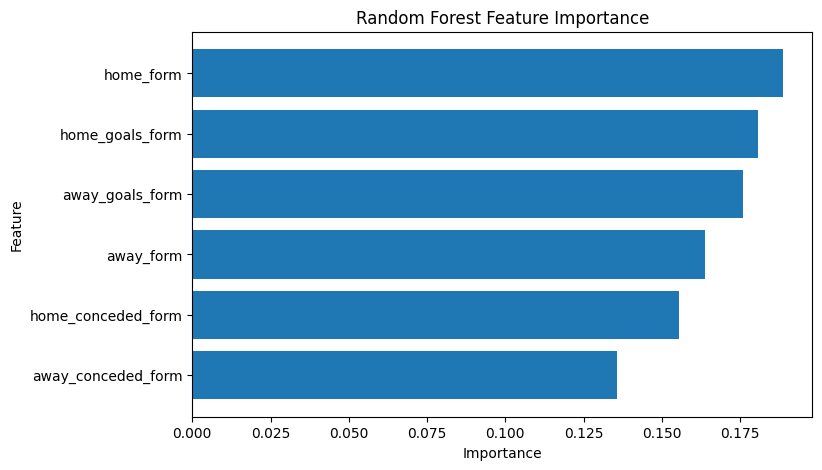

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')

plt.gca().invert_yaxis()
plt.show()

In [60]:
print(classification_report(
    y_test,
    balanced_pred,
    labels=['H', 'D', 'A'],
    target_names=['Home Win', 'Draw', 'Away Win']
))

              precision    recall  f1-score   support

    Home Win       0.51      0.53      0.52       256
        Draw       0.22      0.21      0.21       151
    Away Win       0.40      0.40      0.40       177

    accuracy                           0.41       584
   macro avg       0.38      0.38      0.38       584
weighted avg       0.40      0.41      0.40       584



In [61]:
final_results.to_csv(
    "/content/drive/MyDrive/ml/model_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


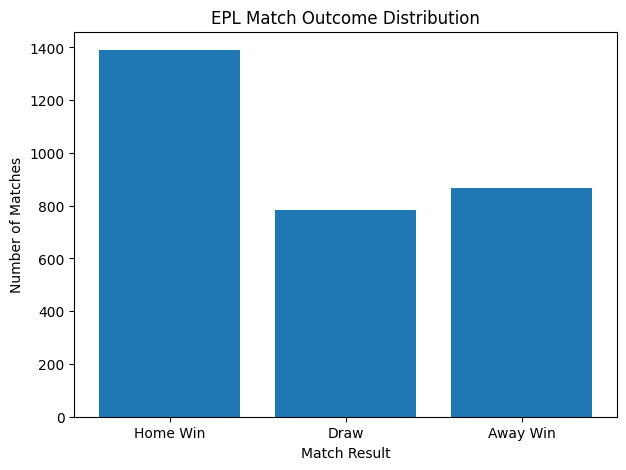

result
H    1390
D     783
A     867
Name: count, dtype: int64


In [62]:
plt.figure(figsize=(7, 5))

result_counts = epl_matches['result'].value_counts().reindex(['H', 'D', 'A'])

plt.bar(
    ['Home Win', 'Draw', 'Away Win'],
    result_counts.values
)

plt.ylabel('Number of Matches')
plt.xlabel('Match Result')
plt.title('EPL Match Outcome Distribution')

plt.show()

print(result_counts)

In [64]:
form_by_result = (
    epl_matches
    .groupby('result')['home_form']
    .mean()
    .reindex(['H', 'D', 'A'])
)

print(form_by_result)

result
H    1.462098
D    1.273499
A    1.207228
Name: home_form, dtype: float64


In [65]:
form_by_result_away = (
    epl_matches
    .groupby('result')['away_form']
    .mean()
    .reindex(['H', 'D', 'A'])
)

print(form_by_result_away)

result
H    1.290228
D    1.401171
A    1.545098
Name: away_form, dtype: float64


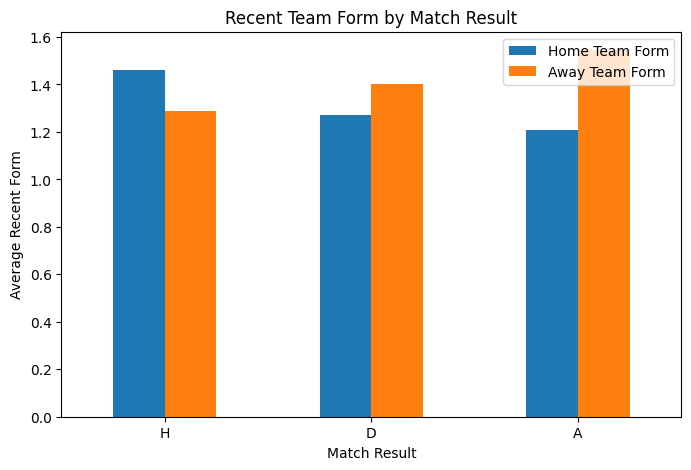

In [66]:
form_summary = pd.DataFrame({
    'Home Team Form': form_by_result,
    'Away Team Form': form_by_result_away
})

form_summary.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel('Match Result')
plt.ylabel('Average Recent Form')
plt.title('Recent Team Form by Match Result')
plt.xticks(rotation=0)
plt.legend()
plt.show()

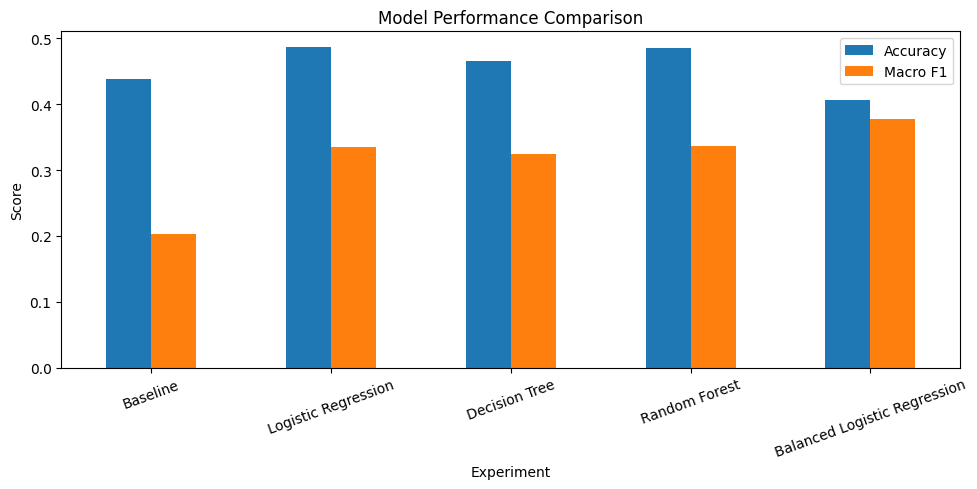

In [67]:
final_results.plot(
    x='Experiment',
    y=['Accuracy', 'Macro F1'],
    kind='bar',
    figsize=(10, 5)
)

plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
decision_log = pd.DataFrame({
    'Decision': [
        'Primary business lens',
        'ML task',
        'Target',
        'Feature strategy',
        'Data split',
        'Baseline',
        'Alternative models',
        'Class imbalance experiment',
        'Evaluation metrics'
    ],

    'Our decision': [
        'Match outcome analysis',
        '3-class classification',
        'H / D / A',
        'Use only information available before each match',
        'Chronological 80/20 split',
        'Most-frequent-class baseline',
        'Logistic Regression, Decision Tree, Random Forest',
        'Balanced Logistic Regression',
        'Accuracy, Macro F1, precision, recall, confusion matrix'
    ],

    'Reason': [
        'Matches the selected Sports Analytics decision lens',
        'Predict the outcome category of a future match',
        'Represents home win, draw, or away win',
        'Prevent information leakage from the future',
        'Simulates predicting future matches using past matches',
        'Provides a simple reference point',
        'Compare different model types using the same task',
        'Investigate the very weak draw prediction',
        'Accuracy alone does not show class-level performance'
    ]
})

display(decision_log)

,Decision,Our decision,Reason
0,Primary business lens,Match outcome analysis,Matches the selected Sports Analytics decision...
1,ML task,3-class classification,Predict the outcome category of a future match
2,Target,H / D / A,"Represents home win, draw, or away win"
3,Feature strategy,Use only information available before each match,Prevent information leakage from the future
4,Data split,Chronological 80/20 split,Simulates predicting future matches using past...
5,Baseline,Most-frequent-class baseline,Provides a simple reference point
6,Alternative models,"Logistic Regression, Decision Tree, Random Forest",Compare different model types using the same task
7,Class imbalance experiment,Balanced Logistic Regression,Investigate the very weak draw prediction
8,Evaluation metrics,"Accuracy, Macro F1, precision, recall, confusi...",Accuracy alone does not show class-level perfo...


In [69]:
eda_log = pd.DataFrame({
    'EDA analysis': [
        'Match outcome distribution',
        'Home-team form by result',
        'Away-team form by result',
        'Feature importance'
    ],

    'Finding': [
        'Home wins were the most common outcome, followed by away wins and draws.',
        'Matches ending in home wins had the highest average previous home-team form.',
        'Matches ending in away wins had the highest average previous away-team form.',
        'Home form was the most important feature in the Random Forest model.'
    ],

    'Why it matters': [
        'The target classes are not equally distributed, so accuracy alone may be misleading.',
        'Recent home-team performance contains useful information for predicting outcomes.',
        'Recent away-team performance also contains useful information for predicting outcomes.',
        'The model relies substantially on recent team performance information.'
    ]
})

display(eda_log)

,EDA analysis,Finding,Why it matters
0,Match outcome distribution,"Home wins were the most common outcome, follow...",The target classes are not equally distributed...
1,Home-team form by result,Matches ending in home wins had the highest av...,Recent home-team performance contains useful i...
2,Away-team form by result,Matches ending in away wins had the highest av...,Recent away-team performance also contains use...
3,Feature importance,Home form was the most important feature in th...,The model relies substantially on recent team ...


In [70]:
feature_log = pd.DataFrame({
    'Step': [
        'Filter dataset',
        'Create target',
        'Sort by date',
        'Create recent form',
        'Create goal-scoring form',
        'Create goals-conceded form',
        'Remove unavailable early matches',
        'Train/test split'
    ],

    'What we did': [
        'Selected English Premier League matches',
        'Created H / D / A from final match goals',
        'Ordered matches chronologically',
        'Calculated previous-match performance for each team',
        'Calculated previous average goals scored',
        'Calculated previous average goals conceded',
        'Removed matches where previous-match features were not available',
        'Used earlier matches for training and later matches for testing'
    ],

    'Purpose': [
        'Keep the project focused on the selected decision problem',
        'Create the classification target',
        'Preserve the time order of the data',
        'Represent recent team performance before a match',
        'Represent recent attacking performance',
        'Represent recent defensive performance',
        'Avoid missing/invalid feature values',
        'Simulate predicting future matches from past information'
    ]
})

display(feature_log)

,Step,What we did,Purpose
0,Filter dataset,Selected English Premier League matches,Keep the project focused on the selected decis...
1,Create target,Created H / D / A from final match goals,Create the classification target
2,Sort by date,Ordered matches chronologically,Preserve the time order of the data
3,Create recent form,Calculated previous-match performance for each...,Represent recent team performance before a match
4,Create goal-scoring form,Calculated previous average goals scored,Represent recent attacking performance
5,Create goals-conceded form,Calculated previous average goals conceded,Represent recent defensive performance
6,Remove unavailable early matches,Removed matches where previous-match features ...,Avoid missing/invalid feature values
7,Train/test split,Used earlier matches for training and later ma...,Simulate predicting future matches from past i...


In [71]:
decision_log.to_csv(
    "/content/drive/MyDrive/ml/decision_log.csv",
    index=False
)

eda_log.to_csv(
    "/content/drive/MyDrive/ml/eda_log.csv",
    index=False
)

feature_log.to_csv(
    "/content/drive/MyDrive/ml/feature_log.csv",
    index=False
)

print("All project logs saved successfully!")

All project logs saved successfully!


In [72]:
final_findings = pd.DataFrame({
    "Area": [
        "Target distribution",
        "Recent form",
        "Model comparison",
        "Draw prediction",
        "Class balancing",
        "Feature importance"
    ],

    "Finding": [
        "Home wins were the most common outcome (45.72%), followed by away wins (28.52%) and draws (25.76%).",
        "Home wins were associated with higher average recent home form, while away wins were associated with higher average recent away form.",
        "Standard Logistic Regression and Random Forest achieved similar accuracy, around 48%, and both improved over the majority-class baseline.",
        "Draws were difficult to identify using the original features; standard models had very low draw recall.",
        "Balanced Logistic Regression reduced accuracy to 40.58% but increased macro F1 to 0.3771 and improved draw recall to 21%.",
        "Random Forest feature importance showed recent home/away form, goals scored, and goals conceded all contributed to predictions."
    ],

    "Evidence": [
        "Target distribution analysis",
        "EDA comparison of home_form and away_form",
        "Model comparison results",
        "Classification reports and confusion matrices",
        "Balanced Logistic Regression experiment",
        "Random Forest feature importance"
    ]
})

final_findings

,Area,Finding,Evidence
0,Target distribution,Home wins were the most common outcome (45.72%...,Target distribution analysis
1,Recent form,Home wins were associated with higher average ...,EDA comparison of home_form and away_form
2,Model comparison,Standard Logistic Regression and Random Forest...,Model comparison results
3,Draw prediction,Draws were difficult to identify using the ori...,Classification reports and confusion matrices
4,Class balancing,Balanced Logistic Regression reduced accuracy ...,Balanced Logistic Regression experiment
5,Feature importance,Random Forest feature importance showed recent...,Random Forest feature importance


In [73]:
final_findings.to_csv(
    "/content/drive/MyDrive/ml/final_findings.csv",
    index=False
)

print("Final findings saved successfully.")

Final findings saved successfully.


In [74]:
limitations = pd.DataFrame({
    "Limitation": [
        "Limited feature set",
        "Draw prediction remains difficult",
        "Historical rather than current-season deployment",
        "Class imbalance",
        "Five-match form window",
        "Model performance is moderate"
    ],

    "Impact": [
        "The model uses recent form, goals scored and goals conceded, but does not include other potentially useful pre-match information.",
        "Even after class balancing, draw recognition remained difficult.",
        "The historical dataset does not guarantee that performance would remain the same in a future season.",
        "The outcome classes are not evenly distributed, which affects model learning and evaluation.",
        "Using only the previous five matches may miss longer-term team performance patterns.",
        "The models provide useful predictive signals but are not highly accurate enough to treat predictions as certain."
    ]
})

limitations

,Limitation,Impact
0,Limited feature set,"The model uses recent form, goals scored and g..."
1,Draw prediction remains difficult,"Even after class balancing, draw recognition r..."
2,Historical rather than current-season deployment,The historical dataset does not guarantee that...
3,Class imbalance,The outcome classes are not evenly distributed...
4,Five-match form window,Using only the previous five matches may miss ...
5,Model performance is moderate,The models provide useful predictive signals b...


In [75]:
limitations.to_csv(
    "/content/drive/MyDrive/ml/limitations.csv",
    index=False
)

print("Limitations saved successfully.")

Limitations saved successfully.


In [76]:
problem_framing = pd.DataFrame({
    "Component": [
        "Business / Analytical Problem",
        "Stakeholder",
        "Decision to Support",
        "Prediction Target",
        "ML Task",
        "Input Data",
        "Success Measures",
        "Main Constraint",
        "Potential Value"
    ],

    "Description": [
        "Analyse whether pre-match team performance information can be used to predict the outcome of an English Premier League football match.",
        "Football match analyst or team decision-maker.",
        "Use pre-match information to estimate whether a match is likely to end in a home win, draw, or away win.",
        "Full-time match result: H (Home Win), D (Draw), A (Away Win).",
        "Three-class classification.",
        "Previous-match form, goals scored, goals conceded, and home/away-specific recent form.",
        "Accuracy, macro F1, precision, recall, and confusion matrix.",
        "Only information available before the match should be used; post-match information must not leak into the features.",
        "Provide evidence about whether recent team performance contains useful information for predicting match outcomes."
    ]
})

problem_framing

,Component,Description
0,Business / Analytical Problem,Analyse whether pre-match team performance inf...
1,Stakeholder,Football match analyst or team decision-maker.
2,Decision to Support,Use pre-match information to estimate whether ...
3,Prediction Target,"Full-time match result: H (Home Win), D (Draw)..."
4,ML Task,Three-class classification.
5,Input Data,"Previous-match form, goals scored, goals conce..."
6,Success Measures,"Accuracy, macro F1, precision, recall, and con..."
7,Main Constraint,Only information available before the match sh...
8,Potential Value,Provide evidence about whether recent team per...


In [77]:
problem_framing.to_csv(
    "/content/drive/MyDrive/ml/problem_framing_canvas.csv",
    index=False
)

print("Problem framing canvas saved successfully.")

Problem framing canvas saved successfully.


In [78]:
workflow_steps = pd.DataFrame({
    "Step": range(1, 11),
    "Stage": [
        "Data acquisition",
        "Data inspection",
        "Data filtering",
        "Target creation",
        "Feature engineering",
        "EDA",
        "Data splitting",
        "Model training",
        "Model evaluation",
        "Findings & recommendation"
    ],

    "What we did": [
        "Loaded the Kaggle European Soccer Database SQLite file.",
        "Inspected the database tables, columns and available football match information.",
        "Filtered the Match table to English Premier League matches.",
        "Created H/D/A outcome labels from home and away goals.",
        "Calculated pre-match recent form, goals scored and goals conceded using previous matches only.",
        "Examined outcome distribution and relationships between recent form and match results.",
        "Split the data chronologically into 80% training and 20% testing data.",
        "Trained a baseline, Logistic Regression, Decision Tree and Random Forest, followed by balanced Logistic Regression.",
        "Compared accuracy, macro F1, precision, recall and confusion matrices.",
        "Identified useful signals, documented limitations and considered the trade-off between accuracy and balanced class recognition."
    ]
})

workflow_steps

,Step,Stage,What we did
0,1,Data acquisition,Loaded the Kaggle European Soccer Database SQL...
1,2,Data inspection,"Inspected the database tables, columns and ava..."
2,3,Data filtering,Filtered the Match table to English Premier Le...
3,4,Target creation,Created H/D/A outcome labels from home and awa...
4,5,Feature engineering,"Calculated pre-match recent form, goals scored..."
5,6,EDA,Examined outcome distribution and relationship...
6,7,Data splitting,Split the data chronologically into 80% traini...
7,8,Model training,"Trained a baseline, Logistic Regression, Decis..."
8,9,Model evaluation,"Compared accuracy, macro F1, precision, recall..."
9,10,Findings & recommendation,"Identified useful signals, documented limitati..."


In [79]:
workflow_steps.to_csv(
    "/content/drive/MyDrive/ml/workflow_steps.csv",
    index=False
)

print("Workflow steps saved successfully.")

Workflow steps saved successfully.


In [80]:
data_dictionary = pd.DataFrame({
    "Feature": [
        "date",
        "home_team_api_id",
        "away_team_api_id",
        "home_team_name",
        "away_team_name",
        "home_team_goal",
        "away_team_goal",
        "result",
        "home_form",
        "away_form",
        "home_goals_form",
        "away_goals_form",
        "home_conceded_form",
        "away_conceded_form",
        "home_team_home_form",
        "away_team_away_form"
    ],

    "Description": [
        "Date on which the football match was played.",
        "Identifier of the home team.",
        "Identifier of the away team.",
        "Name of the home team.",
        "Name of the away team.",
        "Number of goals scored by the home team in the match.",
        "Number of goals scored by the away team in the match.",
        "Match outcome: H = Home Win, D = Draw, A = Away Win.",
        "Average points gained by the home team over its previous five matches.",
        "Average points gained by the away team over its previous five matches.",
        "Average goals scored by the home team over its previous five matches.",
        "Average goals scored by the away team over its previous five matches.",
        "Average goals conceded by the home team over its previous five matches.",
        "Average goals conceded by the away team over its previous five matches.",
        "Average points gained by the home team in its previous five home matches.",
        "Average points gained by the away team in its previous five away matches."
    ],

    "Role": [
        "Reference / temporal ordering",
        "Team identification",
        "Team identification",
        "Reference",
        "Reference",
        "Post-match information / target construction",
        "Post-match information / target construction",
        "Target",
        "ML feature",
        "ML feature",
        "ML feature",
        "ML feature",
        "ML feature",
        "ML feature",
        "ML feature in Experiment 2",
        "ML feature in Experiment 2"
    ]
})

data_dictionary

,Feature,Description,Role
0,date,Date on which the football match was played.,Reference / temporal ordering
1,home_team_api_id,Identifier of the home team.,Team identification
2,away_team_api_id,Identifier of the away team.,Team identification
3,home_team_name,Name of the home team.,Reference
4,away_team_name,Name of the away team.,Reference
5,home_team_goal,Number of goals scored by the home team in the...,Post-match information / target construction
6,away_team_goal,Number of goals scored by the away team in the...,Post-match information / target construction
7,result,"Match outcome: H = Home Win, D = Draw, A = Awa...",Target
8,home_form,Average points gained by the home team over it...,ML feature
9,away_form,Average points gained by the away team over it...,ML feature


In [81]:
data_dictionary.to_csv(
    "/content/drive/MyDrive/ml/data_dictionary.csv",
    index=False
)

print("Data dictionary saved successfully.")

Data dictionary saved successfully.
